In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
MODEL_NAME = "AE_2"
BATCH_SIZE = 128
LEARNING_RATE = 0.001
NUM_EPOCHS = 20

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
transform = transforms.ToTensor()

mnist_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

data_loader = torch.utils.data.DataLoader(dataset=mnist_data, batch_size=BATCH_SIZE, shuffle=True)

In [5]:
dataiter = iter(data_loader)
images, labels = next(dataiter)
print(torch.min(images), torch.max(images))

tensor(0.) tensor(1.)


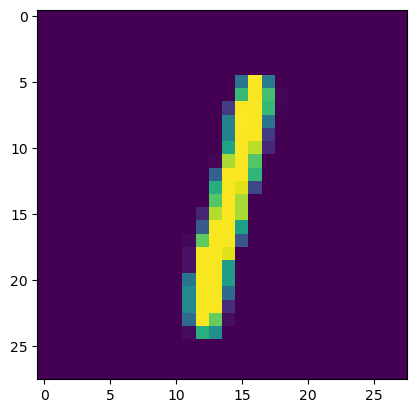

In [6]:
image = images[0]
image = image.permute(1, 2, 0)
plt.imshow(image)

In [7]:
class Reshape(nn.Module):
    def __init__(self, *shape):
        super().__init__()
        self.shape = shape  # this should be the target shape without the batch dim (e.g. (32, 7, 7))

    def forward(self, x):
        return x.view(x.size(0), *self.shape)

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1), # 32 x 14 x 14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 64 x 7 x 7
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 128 x 3 x 3
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128*3*3, 10), # Latent Rep dim. 10
        )

        self.decoder = nn.Sequential(
            nn.Linear(10, 128*3*3),
            nn.ReLU(),
            Reshape(128, 3, 3),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, output_padding=1), # 64 x 7 x 7
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 32 x 14 x 14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # 1 x 28 x 28
            nn.Sigmoid()
        )

    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

In [8]:
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

In [ ]:
loss_values = []
num_epoch = []

model.train()

for epoch in range(NUM_EPOCHS):
    running_loss = 0.0
    for (img, _) in data_loader:

        img = img.to(device)

        encoded, decoded = model(img)
        loss = criterion(decoded, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(data_loader)
    loss_values.append(epoch_loss)
    num_epoch.append(epoch)
    print(f'Epoch:{epoch+1}, Loss:{epoch_loss:.4f}')

torch.save(model.state_dict(), f"{MODEL_NAME}_weights.pth")
print("Model weights saved successfully!")

Epoch:1, Loss:0.1130
Epoch:2, Loss:0.0446
Epoch:3, Loss:0.0179
Epoch:4, Loss:0.0158
Epoch:5, Loss:0.0148
Epoch:6, Loss:0.0142
Epoch:7, Loss:0.0137
Epoch:8, Loss:0.0133
Epoch:9, Loss:0.0130
Epoch:10, Loss:0.0128
Epoch:11, Loss:0.0126
Epoch:12, Loss:0.0124
Epoch:13, Loss:0.0122
Epoch:14, Loss:0.0121
Epoch:15, Loss:0.0120
Epoch:16, Loss:0.0119
Epoch:17, Loss:0.0118
Epoch:18, Loss:0.0118
Epoch:19, Loss:0.0117
Epoch:20, Loss:0.0116
Model weights saved successfully!


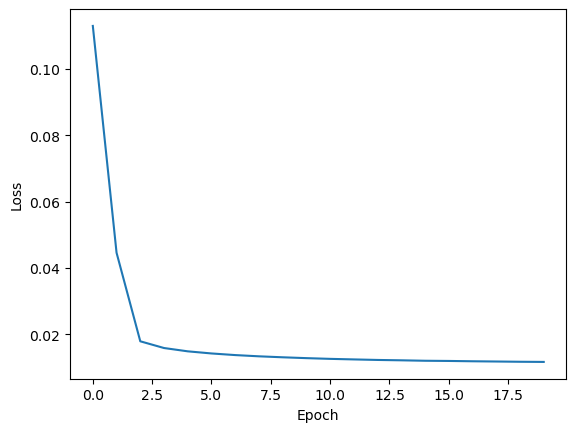

In [10]:
plt.plot(num_epoch, loss_values)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()